In [3]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

df = pd.read_csv('../column_adder/final_processed_dataset.csv')

In [4]:
df

,author,body_text,category,channel,error,link,published_date,scraped_at,title,ner,summary
0,Mikhael Gewati,KOMPAS.com- Dari hamparan pesisir timur hingga...,finance,ekbis,NaN,https://money.kompas.com/read/2025/11/22/09091...,"Kompas.com, 22 November 2025, 09:09 WIB",2025-11-22T16:54:39.469010,"Astra Bergerak Bersama Anak Bangsa, Membangun ...","[{'entity': 'Nusantara', 'type': 'GPE'}, {'ent...",Astra mendukung gerakan pemuda desa melalui pr...
1,NaN,BANKIndonesia telah menurunkan suku bunga acua...,finance,ekbis,NaN,https://money.kompas.com/read/2025/11/22/08434...,"Kompas.com, 22 November 2025, 08:43 WIB",2025-11-22T16:54:37.215084,"Jeratan ""Special Rate"": Pasar Ganda Perbankan","[{'entity': 'BANKIndonesia', 'type': 'ORG'}, {...",Bank Indonesia’s rate cuts since 2024 have fai...
2,Nur Jamal Shaid,"JAKARTA, KOMPAS.com- Harga emas batangan yang ...",finance,ekbis,NaN,https://money.kompas.com/read/2025/11/22/07543...,"Kompas.com, Diperbarui 22/11/2025, 07:55 WIB",2025-11-22T16:54:36.424523,Harga Emas di Pegadaian 22 November 2025: Gale...,"[{'entity': 'JAKARTA', 'type': 'GPE'}, {'entit...",Harga emas batangan Pegadaian turun pada 22 No...
3,"Reni Susanti,","BANDUNG, KOMPAS.com– Vaksin HPV NusaGard, vaks...",finance,ekbis,NaN,https://money.kompas.com/read/2025/11/21/21373...,"Kompas.com, 21 November 2025, 21:37 WIB",2025-11-22T16:54:38.680471,Vaksin HPV Produksi Bio Farma Resmi Kantongi S...,"[{'entity': 'BANDUNG', 'type': 'GPE'}, {'entit...",Vaksin HPV NusaGard buatan Bio Farma resmi dap...
4,Sakina Rakhma Diah Setiawan,"JAKARTA, KOMPAS.com -Iklim usaha yang sehat ti...",finance,ekbis,NaN,https://money.kompas.com/read/2025/11/21/21330...,"Kompas.com, 21 November 2025, 21:33 WIB",2025-11-22T16:54:42.749883,KPPU Soroti Tiga Area Risiko Pelanggaran dalam...,"[{'entity': 'JAKARTA', 'type': 'GPE'}, {'entit...",KPPU menekankan perlindungan proses persaingan...
...,...,...,...,...,...,...,...,...,...,...,...
3111,Nafilah Sri Sagita K -detikHealth,Viral curhat wanita di TikTok sebagai pasangan...,berita-detikhealth,health,NaN,https://health.detik.com/berita-detikhealth/d-...,"Kamis, 20 Nov 2025 16:00 WIB",2025-11-22T13:08:38.505461,Viral Day 3 Nikah Berujung Masuk RS usai Honey...,"[{'entity': 'TikTok', 'type': 'ORG'}, {'entity...",Wanita pengantin baru viral di TikTok karena i...
3112,Sarah Oktaviani Alam -detikHealth,"Seorang YouTuber di Amerika Serikat, Andrew Fe...",berita-detikhealth,health,NaN,https://health.detik.com/berita-detikhealth/d-...,"Kamis, 20 Nov 2025 15:01 WIB",2025-11-22T13:08:39.834112,Youtuber Ikut Eksperimen 'Puasa' Sosmed 30 Har...,"[{'entity': 'Amerika Serikat', 'type': 'GPE'},...",YouTuber Andrew Feinstein menjalani eksperimen...
3113,"Dinda Islami, detikTV -detikHealth",Menko Pangan Zulhas ingin adanya penanda label...,detiktv,health,NaN,https://health.detik.com/detiktv/d-8220147/vid...,"Kamis, 20 Nov 2025 15:00 WIB",2025-11-22T13:08:41.200387,Video: Menko Pangan Mau Ada Label 'Tinggi Gula...,"[{'entity': 'Zulhas', 'type': 'PER'}, {'entity...",Menko Pangan Zulhas mendorong pemberian label ...
3114,Nafilah Sri Sagita K -detikHealth,"Nama Yasika Aulia Ramadhani, perempuan berusia...",berita-detikhealth,health,NaN,https://health.detik.com/berita-detikhealth/d-...,"Kamis, 20 Nov 2025 11:43 WIB",2025-11-22T13:08:42.562160,Kepala BGN soal Anak Waka DPRD Sulsel Punya 41...,"[{'entity': 'Yasika Aulia Ramadhani', 'type': ...","Yasika Aulia, putri politisi, kelola 41 dapur ..."


### 1. Basic Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116 entries, 0 to 3115
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   author          2456 non-null   object 
 1   body_text       3116 non-null   object 
 2   category        3116 non-null   object 
 3   channel         3116 non-null   object 
 4   error           0 non-null      float64
 5   link            3116 non-null   object 
 6   published_date  3088 non-null   object 
 7   scraped_at      3116 non-null   object 
 8   title           3105 non-null   object 
 9   ner             3116 non-null   object 
 10  summary         3116 non-null   object 
dtypes: float64(1), object(10)
memory usage: 267.9+ KB


In [6]:
df.isna().sum()

author             660
body_text            0
category             0
channel              0
error             3116
link                 0
published_date      28
scraped_at           0
title               11
ner                  0
summary              0
dtype: int64

In [7]:
print(f"Number of unique links: {df['link'].nunique()}")
print(f"Number of links: {len(df['link'])}")

Number of unique links: 3116
Number of links: 3116


### 2. Text Related Analysis

In [8]:
text_len = df['body_text'].str.len()
text_len_summary = df['summary'].str.len()
word_count = df['body_text'].str.split().str.len()
word_count_summary = df['summary'].str.split().str.len()

Text(0, 0.5, 'Frequency')

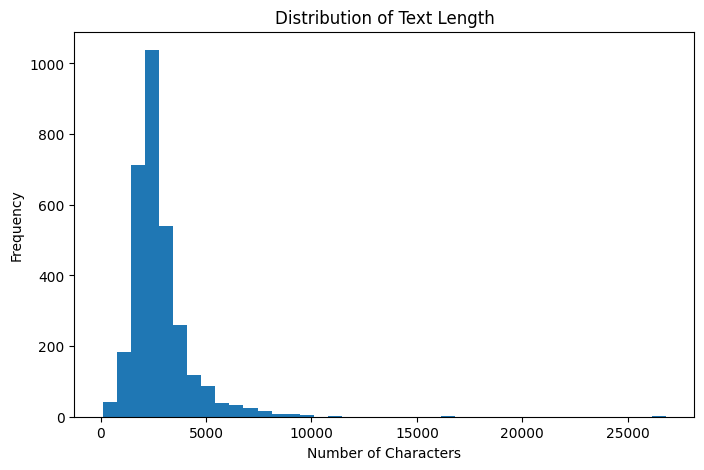

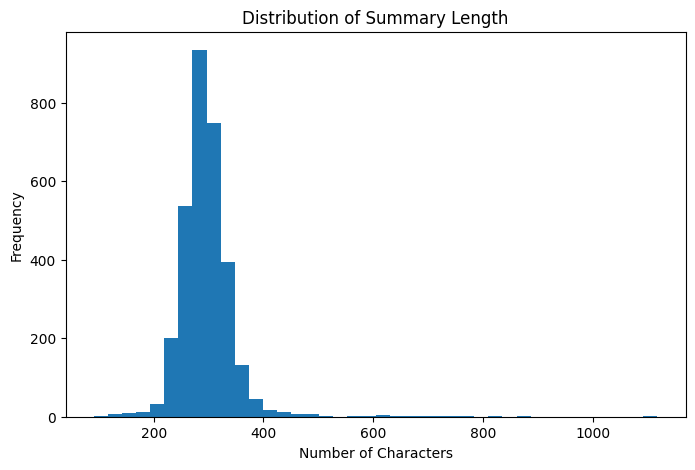

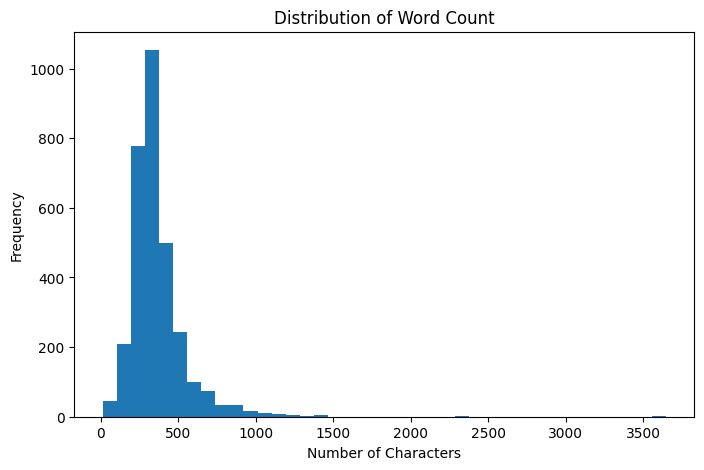

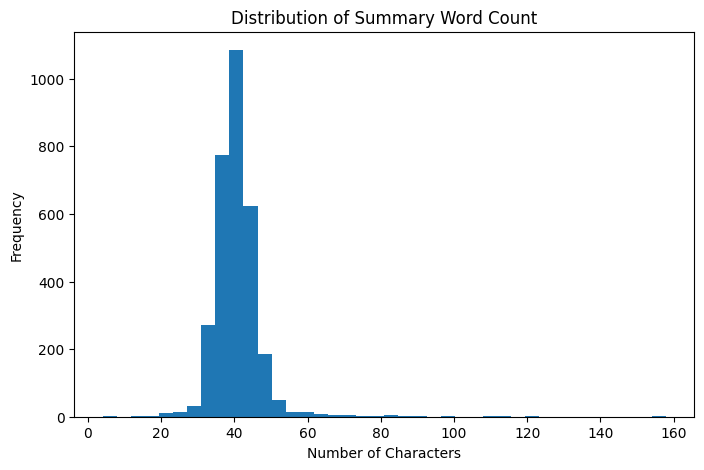

In [9]:
plt.figure(figsize=(8,5))
plt.hist(text_len.dropna(), bins=40)
plt.title("Distribution of Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.figure(figsize=(8,5))
plt.hist(text_len_summary.dropna(), bins=40)
plt.title("Distribution of Summary Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.figure(figsize=(8,5))
plt.hist(word_count.dropna(), bins=40)
plt.title("Distribution of Word Count")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.figure(figsize=(8,5))
plt.hist(word_count_summary.dropna(), bins=40)
plt.title("Distribution of Summary Word Count")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

### 3. Category and Channel Related Analysis

Text(0, 0.5, 'Category Names')

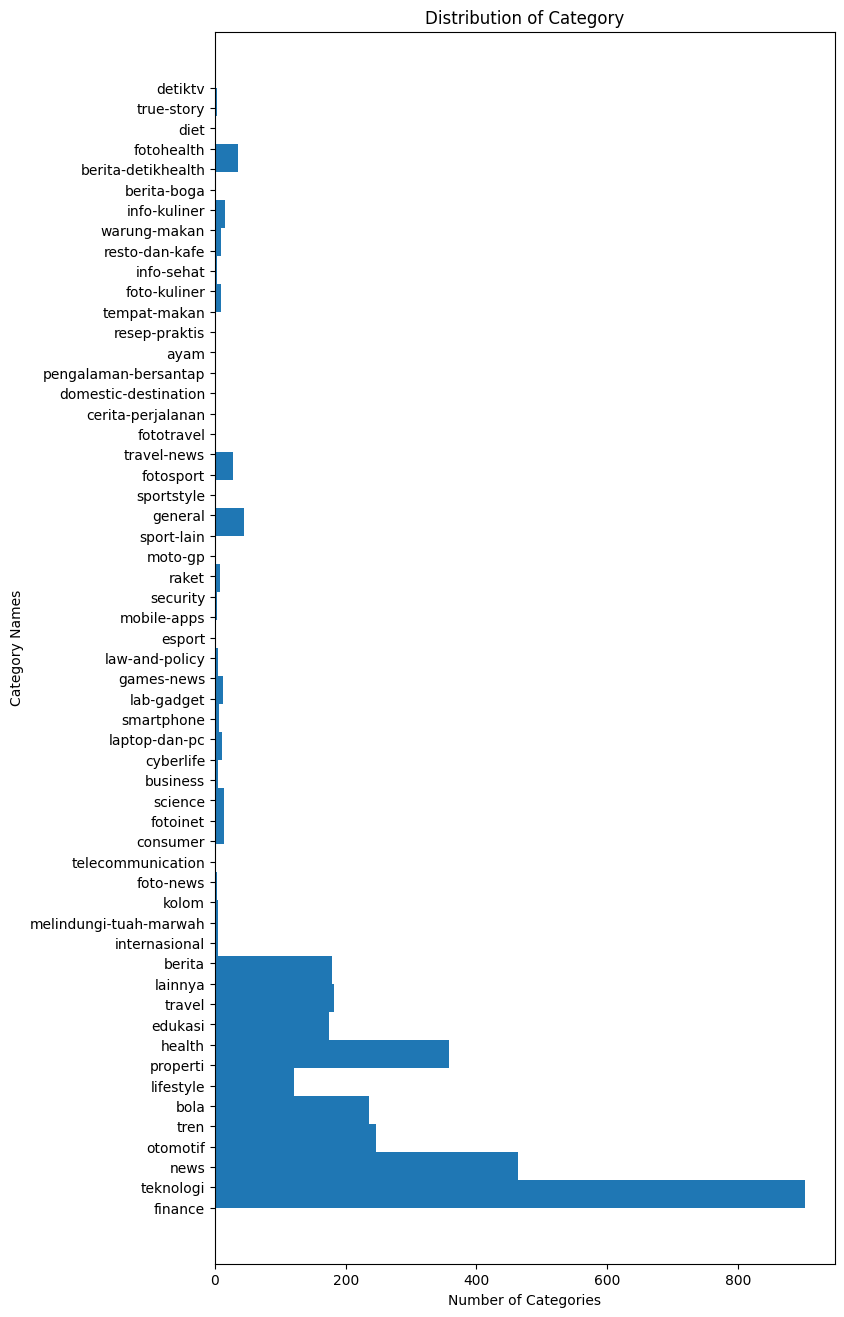

In [10]:
plt.figure(figsize=(8,16))
plt.hist(df['category'].dropna(), bins=40, orientation='horizontal')
plt.title("Distribution of Category")
plt.xlabel("Number of Categories")
plt.ylabel("Category Names")

In [11]:
top_5_category = df['category'].value_counts().head(5)
top_5_category

category
finance     757
news        463
bola        235
otomotif    209
travel      182
Name: count, dtype: int64

Text(0, 0.5, 'Channel Names')

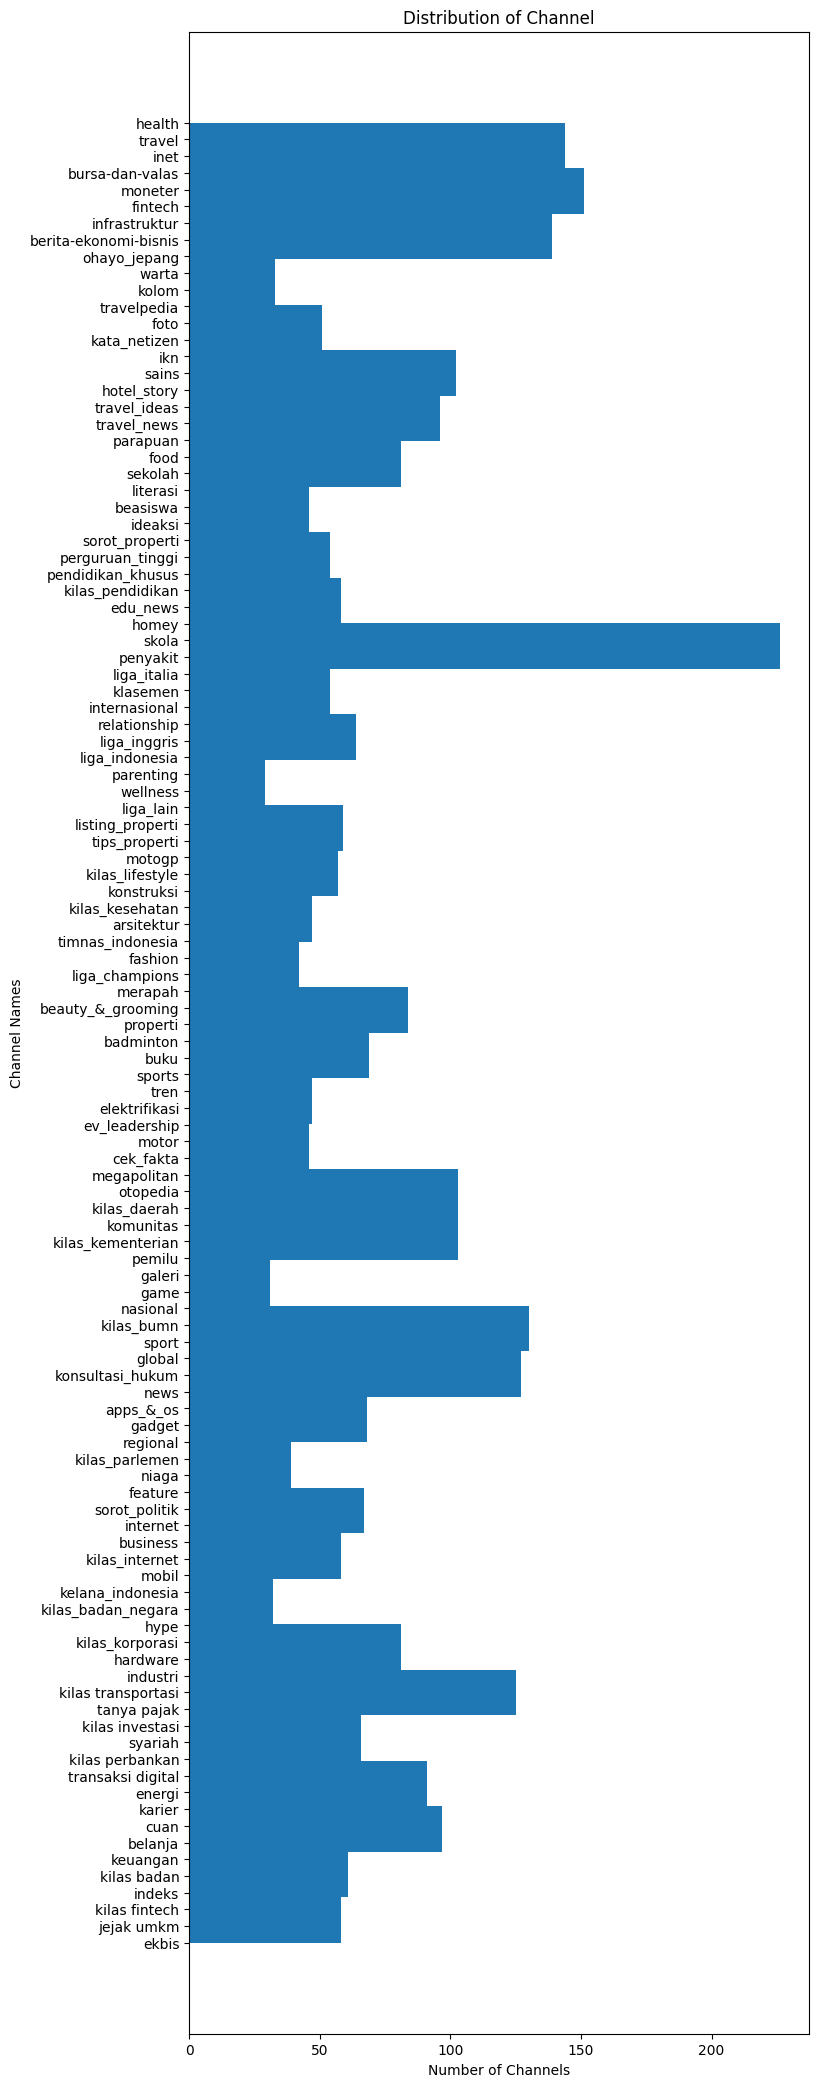

In [12]:
plt.figure(figsize=(8,26))
plt.hist(df['channel'].dropna(), bins=40, orientation='horizontal')
plt.title("Distribution of Channel")
plt.xlabel("Number of Channels")
plt.ylabel("Channel Names")

In [13]:
df['channel'].value_counts().head(5)

channel
penyakit    167
industri     83
energi       81
sport        75
food         74
Name: count, dtype: int64

In [14]:
index_top_5 = top_5_category.index
df_top_5 = df[df['category'].isin(index_top_5)]

In [15]:
pd.crosstab(df_top_5['category'], df['channel'])

channel,badminton,belanja,berita-ekonomi-bisnis,bursa-dan-valas,cek_fakta,cuan,ekbis,elektrifikasi,energi,ev_leadership,...,sorot_politik,sport,sports,syariah,tanya pajak,timnas_indonesia,transaksi digital,travel_ideas,travel_news,travelpedia
category,,,,,,,,,,,,,,,,,,,,,
bola,24,0,0,0,0,0,0,0,0,0,...,0,0,25,0,0,17,0,0,0,0
finance,0,33,57,49,0,32,30,0,81,0,...,0,0,0,33,25,0,10,0,0,0
news,0,0,0,0,18,0,0,0,0,0,...,30,0,0,0,0,0,0,0,0,0
otomotif,0,0,0,0,0,0,0,9,0,8,...,0,20,0,0,0,0,0,0,0,0
travel,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,33,29,29


### 4. NER Related Analysis

In [16]:
def count_ner(x):
    try:
        if pd.isna(x):
            return 0
        parsed = ast.literal_eval(x)
        return len(parsed) if isinstance(parsed, list) else 0
    except:
        return 0

In [17]:
ner_count = df["ner"].apply(count_ner)

Text(0, 0.5, 'Frequency')

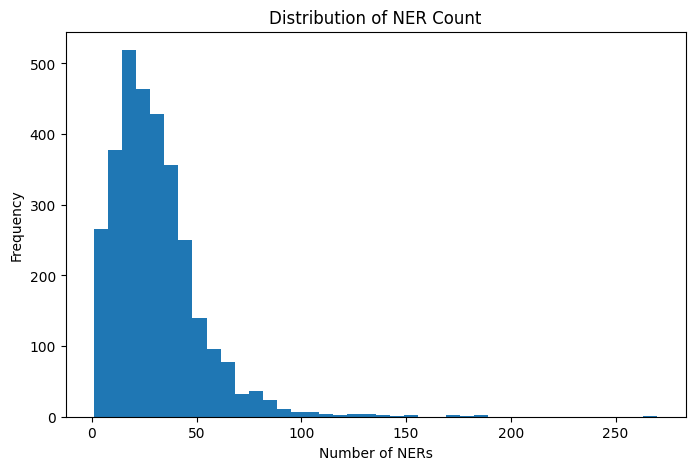

In [18]:
plt.figure(figsize=(8,5))
plt.hist(ner_count.dropna(), bins=40)
plt.title("Distribution of NER Count")
plt.xlabel("Number of NERs")
plt.ylabel("Frequency")

In [19]:
ner_count.value_counts().head(20)

ner
23    89
22    84
27    83
20    78
18    78
15    78
21    75
25    75
19    73
29    72
35    72
24    70
12    70
17    70
28    68
16    67
31    66
33    64
26    63
14    60
Name: count, dtype: int64